# Feature Engineering and Dataset Validation

The objective of this notebook is to prepare the pancreatic cancer dataset for machine learning modelling.
A feature validation process is performed to evaluate biomarker relevance, identify potential data quality issues and construct a refined modelling dataset for pancreatic cancer detection.

In [28]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/pancreatic_600_risk123.csv")

df.head()

,sample_id,patient_cc,sample_o,age,sex,diagnosis,stage,plasma_C,creatinine,LYVE1,REG1B,TFF1,REG1A,CA19_9,CEA,bilirubin,glucose,urine_volume,urine_pH
0,S00111,Cohort1,CPTB,50,M,1,1,8.4501,0.5702,0.1307,79.1530,62.4789,602.2779,248.9139,0.5865,1.2925,108.63,98.4,5.61
1,S00420,Cohort2,BPTB,37,M,3,3,21.4297,0.8658,1.0011,257.8259,165.6953,690.4149,426.4674,8.6544,2.8729,102.61,118.0,6.34
2,S00566,Cohort2,CPTB,80,M,2,2,12.5803,0.8598,2.0098,71.1271,37.2556,721.6129,66.9918,7.6914,1.3359,72.08,7.4,6.14
3,S00078,Cohort1,BPTB,81,M,2,2,10.7277,1.1186,1.0485,114.6138,190.6209,725.6884,177.5647,4.3099,0.4216,120.19,98.8,5.46
4,S00182,Cohort1,BPTB,70,M,2,2,6.1396,1.2448,1.4906,268.5535,173.6363,713.5417,27.8392,4.6962,2.7625,91.05,84.7,6.83


## Diagnosis Mapping

The diagnosis categories are converted into descriptive labels to improve interpretability throughout the validation process.

In [29]:
diagnosis_map = {
    1: "Healthy",
    2: "Benign",
    3: "Pancreatic Cancer"
}

df["diagnosis_label"] = (
    df["diagnosis"]
    .map(diagnosis_map)
)

In [30]:
df[
    [
        "diagnosis",
        "diagnosis_label"
    ]
].drop_duplicates()

,diagnosis,diagnosis_label
0,1,Healthy
1,3,Pancreatic Cancer
2,2,Benign


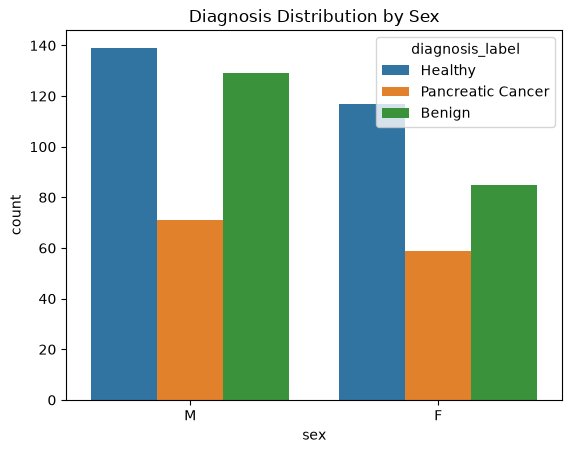

In [31]:
df["sex"].value_counts()

sns.countplot(
    data=df,
    x="sex",
    hue="diagnosis_label"
)

plt.title("Diagnosis Distribution by Sex")
plt.show()

In [33]:
df["sex_encoded"] = (
    df["sex"]
    .map({
        "M": 1,
        "F": 0
    })
)

In [27]:
pd.crosstab(
    df["sex_encoded"],
    df["diagnosis"]
)

diagnosis,1,2,3
sex_encoded,,,
0,117,85,59
1,139,129,71


### Findings

Both male and female patients are represented across all diagnostic categories.
The dataset contains a slightly higher proportion of male patients than female patients in healthy, benign and pancreatic cancer groups.
Therefore, sex was retained for further analysis to evaluate whether it provides additional predictive value during model development.

## Feature Significance Assessment

A statistical feature significance analysis is performed to evaluate the relationship between clinical biomarkers and diagnosis categories.
This assessment helps identify the variables with the strongest discriminatory potential before model development.

In [16]:
from sklearn.feature_selection import f_classif

X = df[
    [
        "age",
        "sex_encoded",
        "plasma_C",
        "creatinine",
        "LYVE1",
        "REG1B",
        "TFF1",
        "REG1A",
        "CA19_9",
        "CEA",
        "bilirubin",
        "glucose",
        "urine_volume",
        "urine_pH"
    ]
]

y = df["diagnosis"]

f_scores, p_values = f_classif(
    X, 
    y
)

feature_scores = pd.DataFrame({
    "Feature": X.columns,
    "F_score": f_scores,
    "p_value": p_values
})


feature_scores = (
    feature_scores
    .sort_values(
        by="F_score",
        ascending=False
    )
)

feature_scores

,Feature,F_score,p_value
7,REG1A,548.786733,5.672936e-136
5,REG1B,431.512910,1.166052e-116
8,CA19_9,384.419323,5.147756e-108
6,TFF1,346.578346,1.263467e-100
2,plasma_C,339.441601,3.497667e-99
9,CEA,323.237726,7.570575e-96
10,bilirubin,254.085077,1.461293e-80
4,LYVE1,250.374019,1.092172e-79
3,creatinine,117.118996,1.231149e-43
11,glucose,2.131400,1.195732e-01


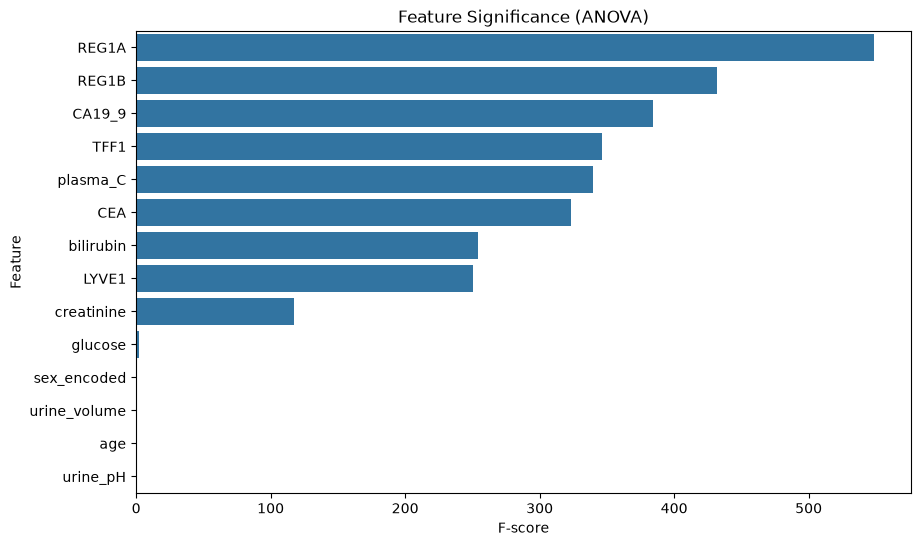

In [17]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_scores,
    x="F_score",
    y="Feature"
)

plt.title("Feature Significance (ANOVA)")
plt.xlabel("F-score")
plt.ylabel("Feature")

plt.show()

### Findings

REG1A, REG1B, CA19-9, TFF1, plasma_C and CEA emerged as the most significant biomarkers.
These variables exhibit strong statistical relationships with diagnosis status and are expected to play an important role during predictive modelling.
In contrast, age, urine pH, sex, urine volume and glucose showed limited discriminatory power.

## Outlier Assessment

Clinical biomarkers are examined for extreme values that may influence model performance.
Identifying outliers is particularly important in medical datasets, as extreme biomarker measurements may represent clinically meaningful observations rather than data quality issues.


In [19]:
biomarkers = [
    "age",
    "sex_encoded",
    "plasma_C",
    "creatinine",
    "LYVE1",
    "REG1B",
    "TFF1",
    "REG1A",
    "CA19_9",
    "CEA",
    "bilirubin",
    "glucose",
    "urine_volume",
    "urine_pH"
]

df[biomarkers].describe().T

,count,mean,std,min,25%,50%,75%,max
age,600.0,57.028333,16.123403,30.0000,43.000000,57.00000,71.250000,85.0000
sex_encoded,600.0,0.565000,0.496171,0.0000,0.000000,1.00000,1.000000,1.0000
plasma_C,600.0,13.110681,5.936106,0.2950,9.064550,12.44700,16.959100,33.0420
creatinine,600.0,1.051478,0.285160,0.0901,0.853850,1.05185,1.243300,1.7857
LYVE1,600.0,0.923620,0.523753,0.0143,0.505550,0.86770,1.281850,2.6003
REG1B,600.0,127.968612,71.701619,0.3862,75.175825,119.18410,185.633875,325.6173
TFF1,600.0,148.338573,91.656459,1.3268,77.443200,139.87930,205.363825,437.2671
REG1A,600.0,678.683848,69.879088,504.6338,624.786475,679.02005,731.210700,869.0944
CA19_9,600.0,193.808119,150.798899,0.2088,76.629775,153.84955,295.639325,770.6011
CEA,600.0,4.104647,2.616863,0.0021,1.990400,3.81950,5.846650,12.9217


### Biomarker Distribution and Outliers

Boxplots are used to visually assess the presence of extreme biomarker values.

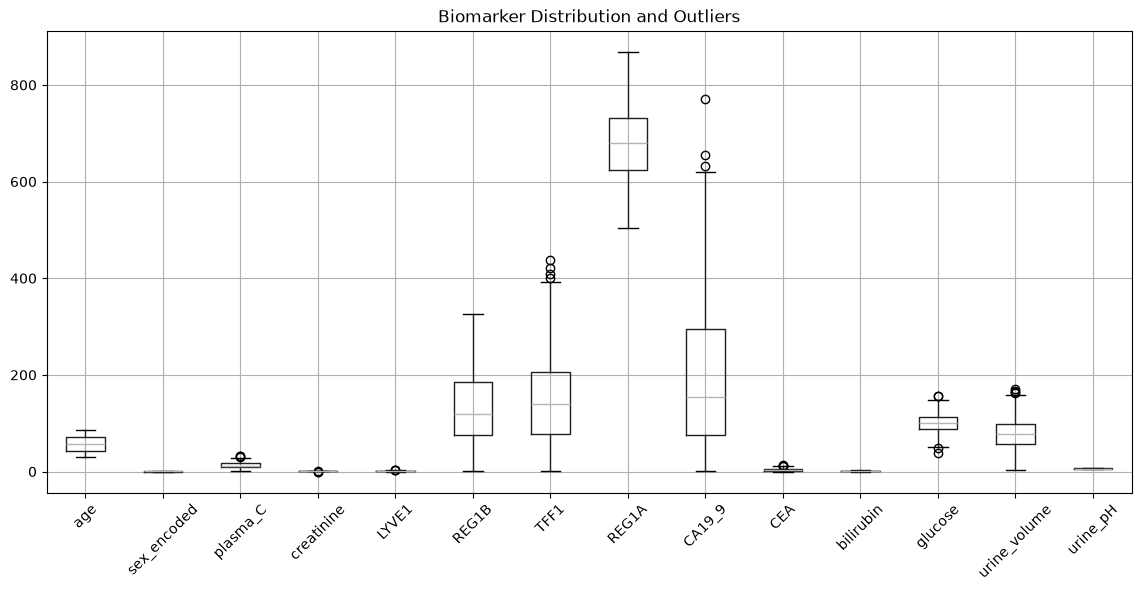

In [20]:
plt.figure(figsize=(14,6))

df[biomarkers].boxplot(rot=45)

plt.title("Biomarker Distribution and Outliers")

plt.show()

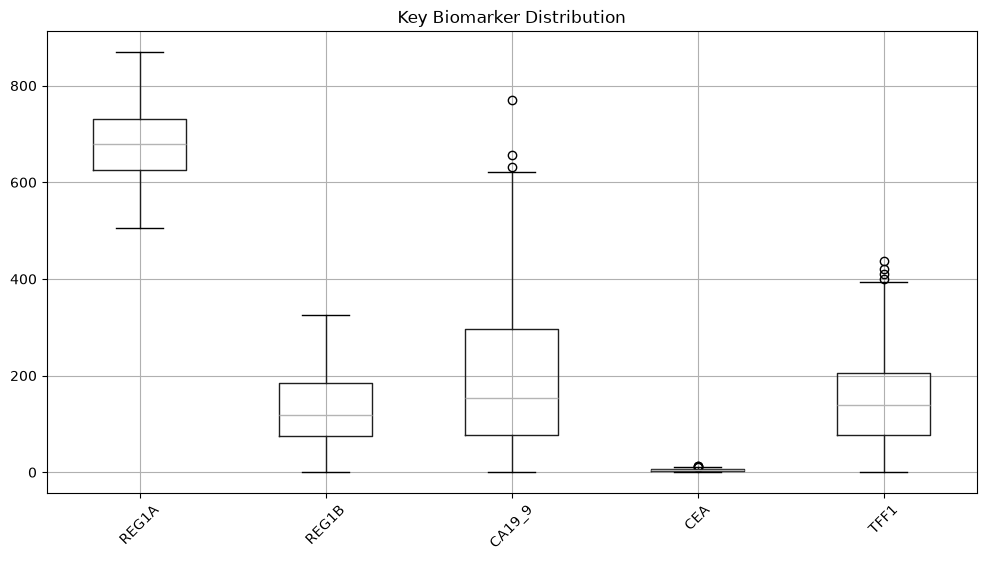

In [14]:
important_biomarkers = [
    "REG1A",
    "REG1B",
    "CA19_9",
    "CEA",
    "TFF1"
]

plt.figure(figsize=(12,6))

df[important_biomarkers].boxplot(rot=45)

plt.title("Key Biomarker Distribution")

plt.show()

### Findings

Several biomarkers exhibit extreme values, particularly REG1A, CA19-9 and TFF1.
However, these observations do not appear to be data quality issues. Instead, they are likely to represent clinically meaningful measurements associated with disease progression.
The most relevant biomarkers identified during exploratory analysis display broad distributions and distinct ranges, suggesting substantial variation between patients.
Consequently, no outlier removal is performed at this stage, as eliminating these observations could remove important clinical information.

Extreme biomarker values were retained because they are likely to reflect genuine clinical variation rather than measurement errors.
Removing these observations could reduce the model's ability to identify high-risk patients.

## Multicollinearity Assessment

The relationships between biomarkers are evaluated to identify potential redundancy among clinical variables.
Variance Inflation Factor (VIF) is used to assess whether multiple biomarkers capture similar information.

In [22]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = df[
    [
        "age",
        "sex_encoded",
        "plasma_C",
        "creatinine",
        "LYVE1",
        "REG1B",
        "TFF1",
        "REG1A",
        "CA19_9",
        "CEA",
        "bilirubin",
        "glucose",
        "urine_volume",
        "urine_pH"
    ]
]

vif = pd.DataFrame()

vif["Feature"] = X_vif.columns

vif["VIF"] = [
    variance_inflation_factor(
        X_vif.values,
        i
    )
    for i in range(len(X_vif.columns))
]

vif.sort_values(
    by="VIF",
    ascending=False
)

,Feature,VIF
7,REG1A,2.286624
5,REG1B,2.154538
6,TFF1,2.025089
2,plasma_C,1.945605
8,CA19_9,1.900757
9,CEA,1.898166
10,bilirubin,1.745752
4,LYVE1,1.713796
3,creatinine,1.352913
0,age,1.039333


### Findings

No evidence of problematic multicollinearity was identified among the clinical biomarkers.
All VIF values remain well below common thresholds of concern, with the highest value observed for REG1A (2.28).
These results indicate that the biomarkers provide largely complementary information and can be retained for modelling without introducing severe redundancy.

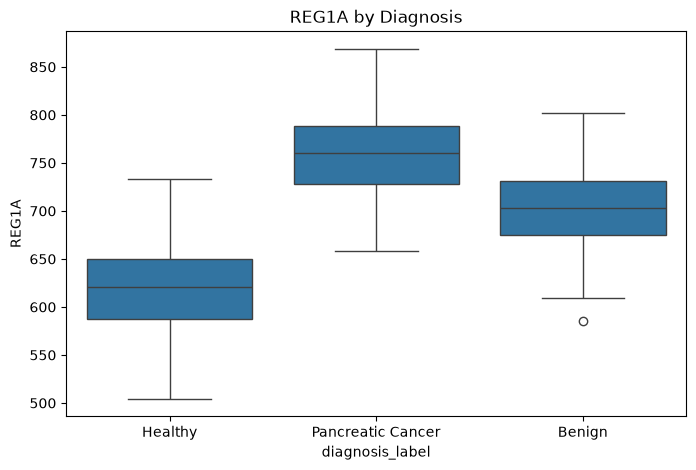

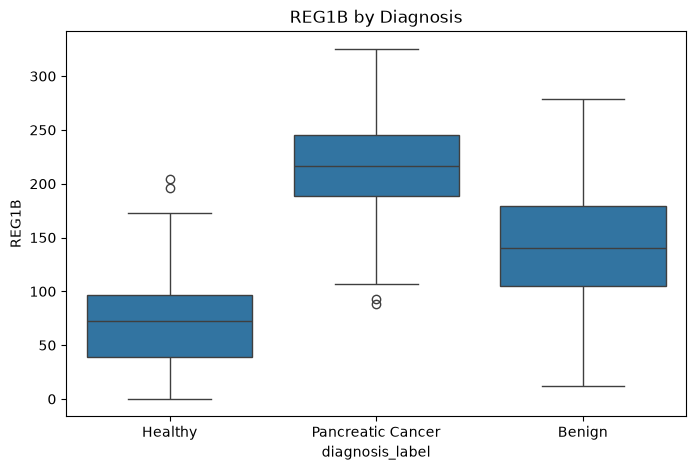

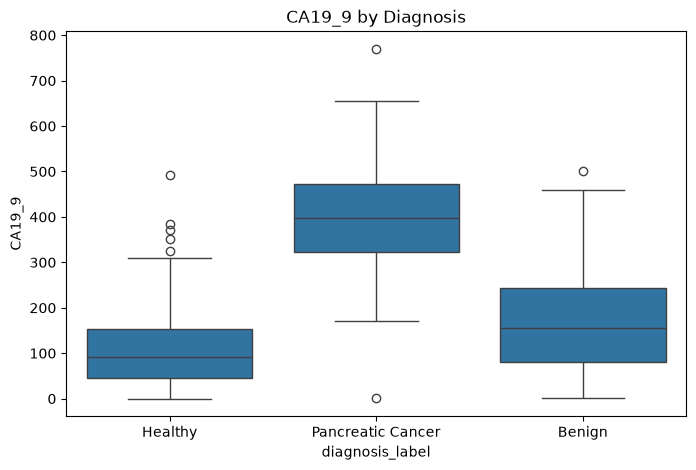

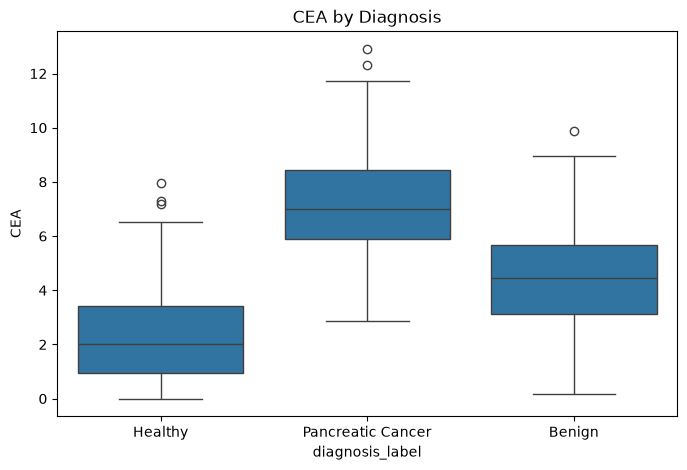

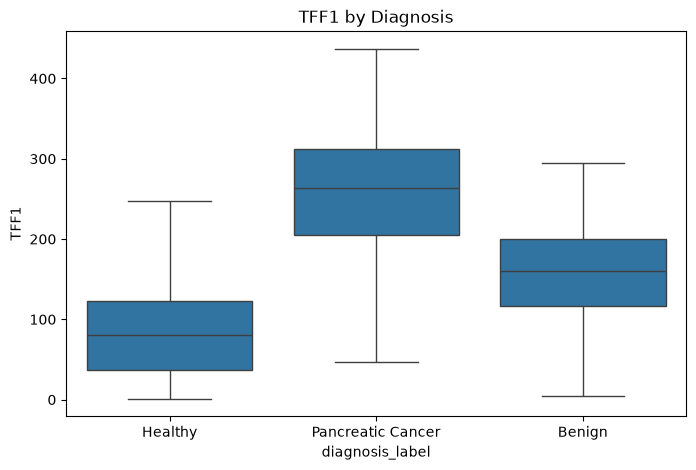

In [23]:
important_biomarkers = [
    "REG1A",
    "REG1B",
    "CA19_9",
    "CEA",
    "TFF1"
]

for feature in important_biomarkers:

    plt.figure(figsize=(8,5))

    sns.boxplot(
        data=df,
        x="diagnosis_label",
        y=feature
    )

    plt.title(f"{feature} by Diagnosis")

    plt.show()

### Findings

The highest biomarker values are predominantly associated with pancreatic cancer patients.
Across REG1A, REG1B, CA19-9, CEA and TFF1, extreme observations consistently appear within the cancer cohort and follow clinically plausible patterns.
These values are therefore interpreted as meaningful biological variation rather than measurement errors. Consequently, no outlier removal was performed.

## Feature Selection and Validation Summary

The feature validation process was conducted to assess the usefulness and reliability of the available clinical biomarkers.
Several biomarkers, particularly REG1A, REG1B, TFF1, CA19-9 and CEA, exhibited strong relationships with diagnosis status and clear separation between patient groups
Outlier analysis showed that extreme biomarker values were predominantly associated with pancreatic cancer patients and are therefore considered clinically meaningful rather than erroneous measurements
Multicollinearity assessment indicated low redundancy among variables, with all Variance Inflation Factor (VIF) values remaining below commonly accepted thresholds.
Consequently, all available biomarkers were retained for model development.

In [26]:
df_model = df[
    [
        "diagnosis",
        "age",
        "sex_encoded",
        "plasma_C",
        "creatinine",
        "LYVE1",
        "REG1B",
        "TFF1",
        "REG1A",
        "CA19_9",
        "CEA",
        "bilirubin",
        "glucose",
        "urine_volume",
        "urine_pH"
    ]
]

df_model.head()

,diagnosis,age,sex_encoded,plasma_C,creatinine,LYVE1,REG1B,TFF1,REG1A,CA19_9,CEA,bilirubin,glucose,urine_volume,urine_pH
0,1,50,1,8.4501,0.5702,0.1307,79.1530,62.4789,602.2779,248.9139,0.5865,1.2925,108.63,98.4,5.61
1,3,37,1,21.4297,0.8658,1.0011,257.8259,165.6953,690.4149,426.4674,8.6544,2.8729,102.61,118.0,6.34
2,2,80,1,12.5803,0.8598,2.0098,71.1271,37.2556,721.6129,66.9918,7.6914,1.3359,72.08,7.4,6.14
3,2,81,1,10.7277,1.1186,1.0485,114.6138,190.6209,725.6884,177.5647,4.3099,0.4216,120.19,98.8,5.46
4,2,70,1,6.1396,1.2448,1.4906,268.5535,173.6363,713.5417,27.8392,4.6962,2.7625,91.05,84.7,6.83
